Name: **Vamsi Krishna Pentela**

Assignment Name: **Deliverable 3: Classification, Clustering, and Pattern Mining**

Subject Name: **Advanced Big Data and Data Mining**

**Loading Libraries for Data Analysis and Machine Learning**

The necessary Python libraries were imported for data preparation, visualization, classification, association rule mining, clustering, dimensionality reduction, and model evaluation. A fixed random seed was also used to ensure consistency of results when analyzing.

In [87]:
# Loading libraries for data handling
import pandas as pd
import numpy as np
# Loading libraries for creating visualizations
import matplotlib.pyplot as plt
import seaborn as sns
# Loading tools for splitting data and tuning models
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Loading tools for building machine learning pipelines
from sklearn.pipeline import Pipeline
# Loading classification algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
# Loading functions for association rule analysis
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
# Loading the clustering algorithm
from sklearn.cluster import KMeans
# Loading the dimensionality reduction method
from sklearn.decomposition import PCA
# Loading measures for evaluating model performance
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    silhouette_score
)
# Setting a fixed seed for reproducible results
np.random.seed(42)

**Loading the Telco Customer Churn Dataset**

The Telco Customer Churn dataset was imported from a CSV file to analyse customer behavior. The first 5 records were shown to check the data that were imported.

In [88]:
# Reading the Telco Customer Churn dataset
telco_data = pd.read_csv("E:\Telco-Customer-Churn.csv")
# Showing the first five records
print("\nFirst Five Rows:")
display(telco_data.head())


First Five Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Examining Dataset Information**

The structure of the dataset and more information about variables was checked in info. The output indicated the count of records, column types and non-null values.

In [89]:
# Reviewing the dataset structure and variable details
print("Dataset Information:")
telco_data.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

**Checking Missing Values**

All the columns in the data set were checked for missing entries, using the sum and isnull functions. The results indicated the number of missing records for each variable.

In [90]:
# Counting missing entries across each column
print("\nMissing Values:")
print(telco_data.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


**Checking Duplicates and Numerical Summary**

Records were duplicated to ensure that there were no repeated observations in the data set. Main values and distributions of numeric variables were summarised numerically to view the overall data.

In [91]:
# Counting repeated records in the dataset
print("\nDuplicate Records:", telco_data.duplicated().sum())
# Showing summary statistics for numerical variables
print("\nNumerical Summary:")
display(telco_data.describe())


Duplicate Records: 0

Numerical Summary:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Cleaning the Total Charges Variable**

The TotalCharges variable was converted into a numeric format and invalid entries were identified as missing values. The charges for missing months were filled with the appropriate charge for each specific month and the number of months missing was verified.

In [92]:
# Converting TotalCharges values into numeric form
telco_data["TotalCharges"] = pd.to_numeric(
    telco_data["TotalCharges"],
    errors="coerce"
)
# Counting missing values created during conversion
print("Missing TotalCharges values:")
print(telco_data["TotalCharges"].isnull().sum())
# Replacing missing charges with monthly charge values
telco_data["TotalCharges"] = telco_data["TotalCharges"].fillna(
    telco_data["MonthlyCharges"]
)
# Verifying the remaining missing value count
print("\nTotal missing values after cleaning:")
print(telco_data.isnull().sum().sum())

Missing TotalCharges values:
11

Total missing values after cleaning:
0


**Analyzing Customer Churn Distribution**

The distribution of churn outcomes was analysed by calculating customer churn counts and percentages. The count plot was created to make a visual comparison of customers who stayed on with the company and customers who churned.

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


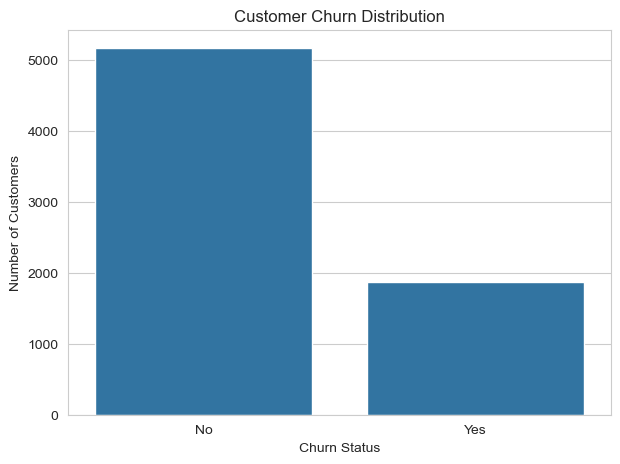

In [93]:
# Counting customers across each churn category
print("Churn Distribution:")
print(telco_data["Churn"].value_counts())
# Calculating the percentage for each churn category
print("\nChurn Percentage:")
print(
    telco_data["Churn"].value_counts(normalize=True).mul(100).round(2)
)
# Creating a count plot for churn categories
plt.figure(figsize=(7, 5))
# Displaying the number of customers in each category
sns.countplot(
    data=telco_data,
    x="Churn"
)
# Adding the chart heading
plt.title("Customer Churn Distribution")
# Naming the horizontal axis
plt.xlabel("Churn Status")
# Naming the vertical axis
plt.ylabel("Number of Customers")
# Displaying the churn distribution chart
plt.show()

The distribution of the customer churn indicates high retention rate of the customers compared to churned customers. The total number of customers that are classified as No Churn is 5174, which accounts for 73.46% of the total number of customers. There are 1869 total customers, who are categorized as Churn, representing 26.54% of customers. The distribution is skewed towards class imbalance in that non-churn customers outnumber churn customers.

**Preparing Variables for Churn Classification**

Before preparation of predictive variables the customer identifier was removed. The values for predictor and churn were kept distinct, and churn categories were transformed into binary values for classification.

In [94]:
# Removing the customer identifier from the predictors
model_data = telco_data.drop(columns=["customerID"])
# Separating predictor variables from the churn outcome
classification_X = model_data.drop(columns=["Churn"])
classification_y = model_data["Churn"].map({
    "No": 0,
    "Yes": 1
})
# Showing the dimensions of the predictor data
print("Predictor Shape:", classification_X.shape)
# Showing the distribution of binary churn outcomes
print("\nTarget Distribution:")
print(classification_y.value_counts())

Predictor Shape: (7043, 19)

Target Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


**Identifying Numerical and Categorical Features**

Data types of predictor variables were classified into numerical and categorical data types. Both feature lists were displayed to support the preprocessing stage.

In [95]:
# Finding variables containing numerical values
numeric_features = classification_X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
# Finding variables containing categorical values
categorical_features = classification_X.select_dtypes(
    include=["object"]
).columns.tolist()
# Showing the numerical feature names
print("Numerical Features:")
print(numeric_features)
# Showing the categorical feature names
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Creating the Data Preprocessing Transformer**

StandardScaler was used to scale numerical variables and OneHotEncoder to encode categorical variables into binary variables to scale each categorical variable. The ColumnTransformer has performed both the pre processing steps and transformed the data into one single process.

In [96]:
# Building the preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)
# Confirming successful transformer creation
print("Preprocessing transformer created successfully.")

Preprocessing transformer created successfully.


**Splitting Data into Training and Testing Sets**

The data set was partitioned into a training set and a test set in the ratio 80:20. The proportions of churn classes were comparable between both groups of samples.

In [97]:
# Dividing the predictors and outcomes into training and testing groups
X_train, X_test, y_train, y_test = train_test_split(
    classification_X,
    classification_y,
    test_size=0.20,
    random_state=42,
    stratify=classification_y
)
# Showing the dimensions of both data groups
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)
# Showing the class proportions in the training group
print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True))
# Showing the class proportions in the testing group
print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True))

Training Set: (5634, 19)
Testing Set: (1409, 19)

Training Target Distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing Target Distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


**Building and Evaluating the Decision Tree Model**

The training data was used to train a Decision Tree classifier with the preprocessing transformer. The accuracy and the F1 score were computed from test predictions, as well as the ROC-AUC and classification results.

In [98]:
# Building the Decision Tree pipeline
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)
# Training the Decision Tree model
decision_tree_pipeline.fit(
    X_train,
    y_train
)
# Producing class predictions for the test data
dt_predictions = decision_tree_pipeline.predict(X_test)
# Producing churn probability estimates for the test data
dt_probabilities = decision_tree_pipeline.predict_proba(X_test)[:, 1]
# Measuring prediction accuracy
dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)
# Measuring the F1 performance score
dt_f1 = f1_score(
    y_test,
    dt_predictions
)
# Measuring the ROC-AUC performance
dt_auc = roc_auc_score(
    y_test,
    dt_probabilities
)
# Showing the Decision Tree performance measures
print("Decision Tree Accuracy:", round(dt_accuracy, 4))
print("Decision Tree F1 Score:", round(dt_f1, 4))
print("Decision Tree ROC-AUC:", round(dt_auc, 4))
# Showing detailed classification results
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        dt_predictions,
        target_names=["No Churn", "Churn"]
    )
)

Decision Tree Accuracy: 0.7942
Decision Tree F1 Score: 0.5821
Decision Tree ROC-AUC: 0.8265

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



The Decision Tree model has an accuracy of 79.42% and a ROC-AUC score of 0.8265, showing that the model performs well overall on the classification task. The model achieves high precision, recall and F1 score for the No Churn prediction of 0.84, 0.89 and 0.86, respectively. The precision of churn prediction is 0.63, the recall is 0.54, and the F1 score is 0.58, which indicates the satisfactory detection capability. The results showed that the classification was reliable and more improvement is required to classify churn customers more effectively.

**Visualizing the Decision Tree Confusion Matrix**

A confusion matrix was set up to determine the churned and not churned class. The classification results were presented using a heatmap to make them easy to visualize for both churn categories.

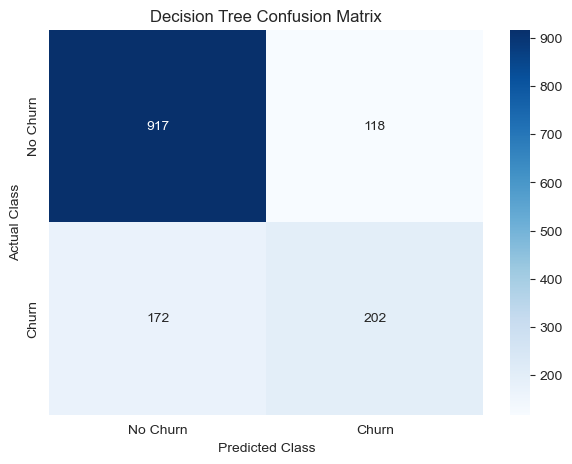

In [99]:
# Calculating the classification confusion matrix
dt_cm = confusion_matrix(
    y_test,
    dt_predictions
)
# Creating a visual display for the confusion matrix
plt.figure(figsize=(7, 5))
# Showing confusion matrix values through a heatmap
sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
# Adding the chart heading
plt.title("Decision Tree Confusion Matrix")
# Naming the predicted class axis
plt.xlabel("Predicted Class")
# Naming the actual class axis
plt.ylabel("Actual Class")
# Displaying the confusion matrix chart
plt.show()

The Decision Tree confusion matrix has correct classification of 917 non churn customers and 202 churn customers. There are 118 non-churn customers who are wrongly classified as churn, and 172 churn customers who are wrongly classified as non-churn. The model shows good performance in the detection of those customers that are not churners and have relatively low classification errors. The findings show that the customers were successfully classified but more improvements are needed to identify the churn cases.

**Building and Evaluating the KNN Model**

The preprocessing transformer was fitted using a KNN classifier and the training data. The test predictions were used to compute accuracy, F1 score, ROC-AUC and classification results.

In [100]:
# Creating the KNN pipeline
knn_pipeline = Pipeline(
steps=[
("preprocessing", preprocessor),
(
"classifier",
KNeighborsClassifier(
n_neighbors=7
)
)
]
)
# Fitting the KNN model with training data
knn_pipeline.fit(
X_train,
y_train
)
# Producing KNN class predictions
knn_predictions = knn_pipeline.predict(X_test)
# Producing probability estimates for churn
knn_probabilities = knn_pipeline.predict_proba(X_test)[:, 1]
# Measuring KNN prediction accuracy
knn_accuracy = accuracy_score(
y_test,
knn_predictions
)
# Measuring the KNN F1 score
knn_f1 = f1_score(
y_test,
knn_predictions
)
# Measuring the KNN ROC-AUC score
knn_auc = roc_auc_score(
y_test,
knn_probabilities
)
# Showing KNN performance results
print("KNN Accuracy:", round(knn_accuracy, 4))
print("KNN F1 Score:", round(knn_f1, 4))
print("KNN ROC-AUC:", round(knn_auc, 4))
# Showing detailed KNN classification results
print("\nClassification Report:")
print(
classification_report(
y_test,
knn_predictions,
target_names=["No Churn", "Churn"]
)
)

KNN Accuracy: 0.7672
KNN F1 Score: 0.5556
KNN ROC-AUC: 0.8019

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.84      1035
       Churn       0.56      0.55      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



The KNN model has an accuracy of 76.72% and a ROC-AUC of 0.8019, which shows that the model has a good overall classification accuracy. The model achieves good results for the prediction of No Churn with accuracy of 0.84, a recall of 0.85 and an F1 of 0.84. The prediction of churn exhibits moderate values with a precision of 0.56, a recall of 0.55 and an F1 of 0.56. The evaluation shows that the classification is balanced and there is room for improvement in the detection of churn customers.

**Visualizing the KNN Confusion Matrix**

The KNN confusion matrix was created and it was compared with actual churn classes. The classification results for both churn outcomes were presented using a heatmap.

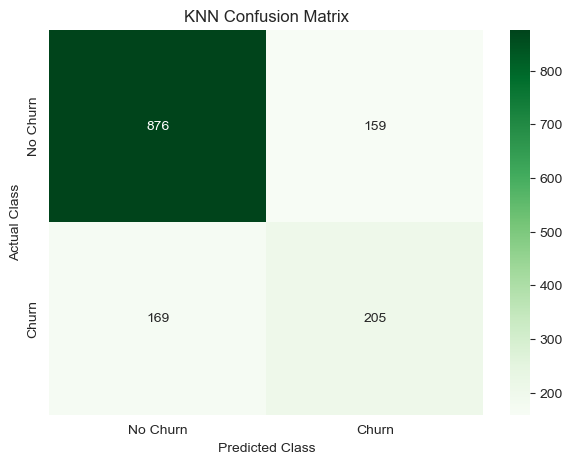

In [101]:
# Calculating the KNN confusion matrix
knn_cm = confusion_matrix(
y_test,
knn_predictions
)
# Preparing the KNN confusion matrix visualization
plt.figure(figsize=(7, 5))
# Displaying the matrix values through a heatmap
sns.heatmap(
knn_cm,
annot=True,
fmt="d",
cmap="Greens",
xticklabels=["No Churn", "Churn"],
yticklabels=["No Churn", "Churn"]
)
# Adding the visualization title
plt.title("KNN Confusion Matrix")
# Labeling the predicted class axis
plt.xlabel("Predicted Class")
# Labeling the actual class axis
plt.ylabel("Actual Class")
# Showing the confusion matrix visualization
plt.show()

The KNN confusion matrix demonstrates the accuracy in classification of 876 non-churn and 205 churn cases. There are 159 non-churn customers that are incorrectly identified as churn and 169 churn cases that are incorrectly identified as non-churn. The model is more effective in predicting non-churned customer than churned customer. These results show that the classification capability is reasonable and further optimization is needed to enhance the accuracy of churn prediction.

**Comparing Classification Model Performance**

Performance results from the Decision Tree and KNN models were combined into a comparison table. Values of accuracy, F1 score and ROC-AUC were rounded and shown for easier model comparison.

In [102]:
# Creating a table for comparing classification models
classification_results = pd.DataFrame({
"Model": [
"Decision Tree",
"KNN"
],
"Accuracy": [
dt_accuracy,
knn_accuracy
],
"F1 Score": [
dt_f1,
knn_f1
],
"ROC-AUC": [
dt_auc,
knn_auc
]
})
# Rounding the model evaluation values
classification_results[
["Accuracy", "F1 Score", "ROC-AUC"]
] = classification_results[
["Accuracy", "F1 Score", "ROC-AUC"]
].round(4)
# Displaying the model comparison results
display(classification_results)

,Model,Accuracy,F1 Score,ROC-AUC
0,Decision Tree,0.7942,0.5821,0.8265
1,KNN,0.7672,0.5556,0.8019


The results of model comparison indicate that the Decision Tree model is better than the KNN model in every evaluation measures. Decision Tree achieves higher accuracy of 79.42%, F1-score of 0.5821, and ROC-AUC of 0.8265. The accuracy, F1-score and ROC-AUC of KNN are 76.72%, 0.5556 and 0.8019 respectively, which are less competitive than Decision Tree. The result shows that the Decision Tree model is the best model for predicting customer churn compared to the other models because of the better overall classification performance among the models.

**Visualizing Classification Model Performance**

The model output was restructured into long format for graphical comparison. A bar chart was constructed to compare accuracy, F1 score and ROC-AUC for both the classification models.

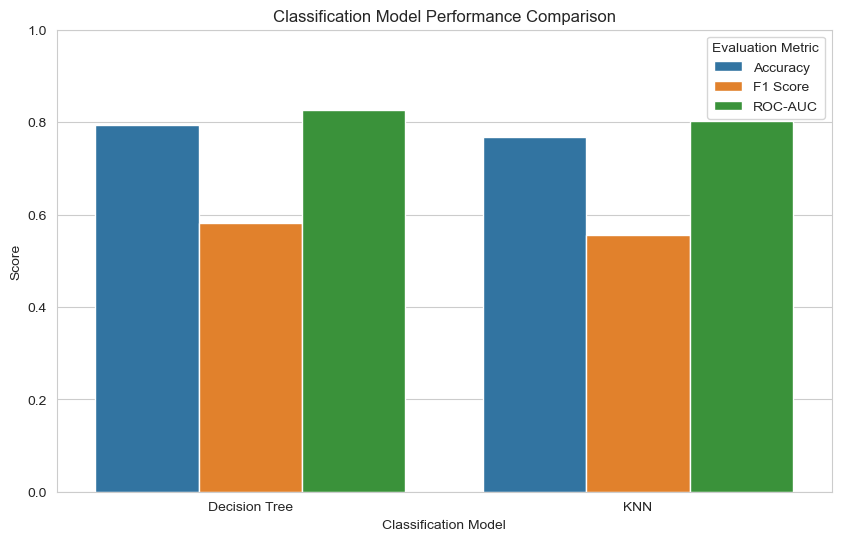

In [103]:
# Reshaping the model results for plotting
performance_long = classification_results.melt(
id_vars="Model",
var_name="Metric",
value_name="Score"
)
# Setting the chart size
plt.figure(figsize=(10, 6))
# Drawing bars for each evaluation metric
sns.barplot(
data=performance_long,
x="Model",
y="Score",
hue="Metric"
)
# Adding the chart title
plt.title("Classification Model Performance Comparison")
# Naming the model axis
plt.xlabel("Classification Model")
# Naming the score axis
plt.ylabel("Score")
# Setting the score range
plt.ylim(0, 1)
# Showing the evaluation metric legend
plt.legend(title="Evaluation Metric")
# Displaying the performance chart
plt.show()

The model performance comparison presents the evaluation metrics of the Decision Tree and KNN classifiers in terms of accuracy, F1 score, and ROC-AUC. The KNN model does not achieve the highest accuracy, F1 score or ROC-AUC value of Decision Tree. The classification capability is good as suggested by the ROC-AUC scores and Decision Tree gives better class separation performance. The results suggest Decision Tree as the more effective model for the given classification task.

**Comparing ROC Curves for Classification Models**

The churn probabilities of these both models were used to calculate roc curve values. AUC values were plotted alongside both curves, for the sake of comparison of the classification performance.

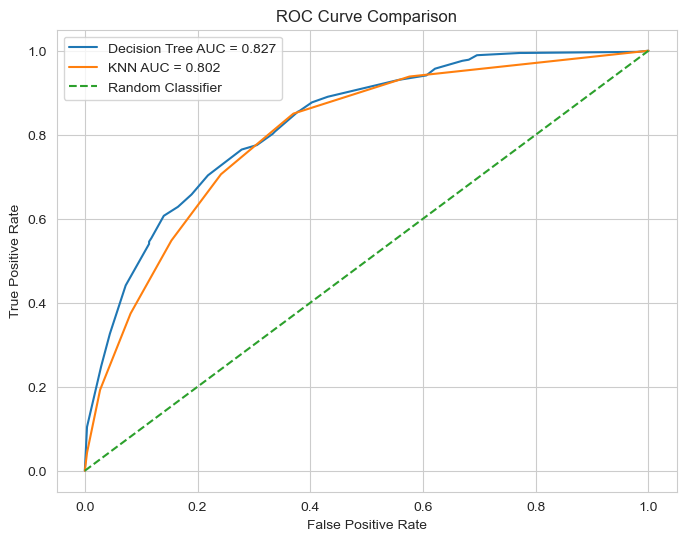

In [104]:
# Calculating ROC coordinates for the Decision Tree
dt_fpr, dt_tpr, _ = roc_curve(
y_test,
dt_probabilities
)
# Calculating ROC coordinates for KNN
knn_fpr, knn_tpr, _ = roc_curve(
y_test,
knn_probabilities
)
# Setting the ROC comparison chart
plt.figure(figsize=(8, 6))
# Drawing the Decision Tree ROC curve
plt.plot(
dt_fpr,
dt_tpr,
label=f"Decision Tree AUC = {dt_auc:.3f}"
)
# Drawing the KNN ROC curve
plt.plot(
knn_fpr,
knn_tpr,
label=f"KNN AUC = {knn_auc:.3f}"
)
# Adding the random prediction reference line
plt.plot(
[0, 1],
[0, 1],
linestyle="--",
label="Random Classifier"
)
# Adding the ROC chart title
plt.title("ROC Curve Comparison")
# Naming the false positive rate axis
plt.xlabel("False Positive Rate")
# Naming the true positive rate axis
plt.ylabel("True Positive Rate")
# Showing the model labels
plt.legend()
# Displaying the ROC comparison
plt.show()

A comparison in terms of classification performances of Decision Tree and KNN models is done based on the AUC values presented in the ROC curve. The model Decision Tree has an AUC value of 0.827, which is higher and has a greater capacity to distinguish between classes. The KNN model achieved an AUC of 0.802 which is competitive, but still less than the AUC of the Decision Tree model. Both models showed good predictive capacity over the random classifier as a baseline.

**Tuning Decision Tree Hyperparameters**

The model parameters in the Decision Trees were cross-validated to determine the best setting of model parameters. The optimal settings and best F1 score obtained by cross validation were then shown.

In [105]:
# Setting parameter combinations for Decision Tree tuning
decision_tree_parameters = {
"classifier__max_depth": [3, 5, 7, 10, None],
"classifier__min_samples_split": [2, 5, 10],
"classifier__min_samples_leaf": [1, 2, 5],
"classifier__criterion": [
"gini",
"entropy"
]
}
# Setting up cross-validation for parameter search
decision_tree_grid = GridSearchCV(
estimator=decision_tree_pipeline,
param_grid=decision_tree_parameters,
cv=5,
scoring="f1",
n_jobs=-1,
verbose=1
)
# Running the hyperparameter search
decision_tree_grid.fit(
X_train,
y_train
)
# Showing the strongest parameter combination
print("Best Parameters:")
print(decision_tree_grid.best_params_)
# Showing the highest cross-validation F1 score
print(
"\nBest Cross-Validation F1 Score:",
round(decision_tree_grid.best_score_, 4)
)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters:
{'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best Cross-Validation F1 Score: 0.5875


**Evaluating the Tuned Decision Tree Model**

Optimized Decision Tree model was used to develop predictions and churn probabilities. The tuned model was tested for accuracy, F1 score, ROC-AUC and classification results.

In [106]:
# Generating predictions from the optimized model
tuned_dt_predictions = decision_tree_grid.predict(
X_test
)
# Generating churn probabilities from the optimized model
tuned_dt_probabilities = decision_tree_grid.predict_proba(
X_test
)[:, 1]
# Calculating accuracy for the optimized model
tuned_dt_accuracy = accuracy_score(
y_test,
tuned_dt_predictions
)
# Calculating F1 score for the optimized model
tuned_dt_f1 = f1_score(
y_test,
tuned_dt_predictions
)
# Calculating ROC-AUC for the optimized model
tuned_dt_auc = roc_auc_score(
y_test,
tuned_dt_probabilities
)
# Showing optimized Decision Tree accuracy
print("Tuned Decision Tree Accuracy:",
round(tuned_dt_accuracy, 4))
# Showing optimized Decision Tree F1 score
print("Tuned Decision Tree F1 Score:",
round(tuned_dt_f1, 4))
# Showing optimized Decision Tree ROC-AUC
print("Tuned Decision Tree ROC-AUC:",
round(tuned_dt_auc, 4))
# Showing the optimized model classification results
print("\nTuned Decision Tree Classification Report:")
print(
classification_report(
y_test,
tuned_dt_predictions,
target_names=["No Churn", "Churn"]
)
)

Tuned Decision Tree Accuracy: 0.7509
Tuned Decision Tree F1 Score: 0.5585
Tuned Decision Tree ROC-AUC: 0.7871

Tuned Decision Tree Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.81      0.83      1035
       Churn       0.53      0.59      0.56       374

    accuracy                           0.75      1409
   macro avg       0.69      0.70      0.69      1409
weighted avg       0.76      0.75      0.76      1409



The tuned Decision Tree model has an accuracy of 75.09%, and a ROC-AUC score of 0.7871, which demonstrates a good overall classification ability. The model has a high precision of 0.85, recall of 0.81 and F1 score of 0.83 in predicting No Churn. The performance of the churn prediction is moderate and the precision is 0.53, the recall is 0.59 and F1 score is 0.56. The results show that the classification of customers is reliable with a need to improve customer classification for churn cases.

**Comparing Original and Tuned Decision Tree Models**

The outputs of the original and optimized Decision Tree were compared and put together in a table. The accuracy, f1 score values and the ROC-AUC values have been rounded and shown to illustrate the effect of the tuning of parameters.

In [107]:
# Building a comparison table for both Decision Tree models
tuning_results = pd.DataFrame({
"Model": [
"Original Decision Tree",
"Tuned Decision Tree"
],
"Accuracy": [
dt_accuracy,
tuned_dt_accuracy
],
"F1 Score": [
dt_f1,
tuned_dt_f1
],
"ROC-AUC": [
dt_auc,
tuned_dt_auc
]
})
# Rounding the evaluation scores
tuning_results[
["Accuracy", "F1 Score", "ROC-AUC"]
] = tuning_results[
["Accuracy", "F1 Score", "ROC-AUC"]
].round(4)
# Displaying the tuning comparison results
display(tuning_results)

,Model,Accuracy,F1 Score,ROC-AUC
0,Original Decision Tree,0.7942,0.5821,0.8265
1,Tuned Decision Tree,0.7509,0.5585,0.7871


**Visualizing the Tuned Decision Tree Confusion Matrix**

The test predictions were used to calculate the confusion matrix of the optimized Decision Tree. A heatmap showed correct and misclassified churn cases in the two churn types.

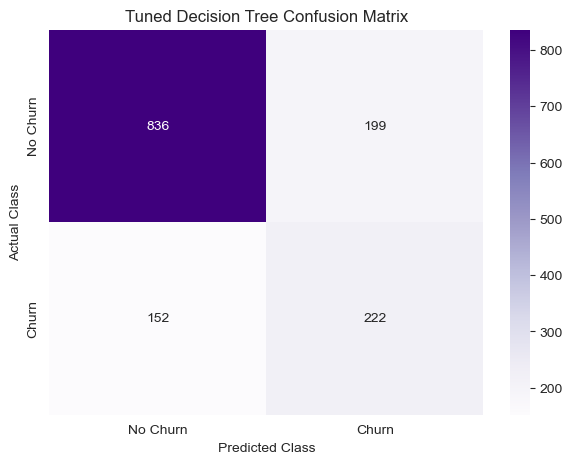

In [108]:
# Calculating the confusion matrix for the tuned model
tuned_cm = confusion_matrix(
y_test,
tuned_dt_predictions
)
# Preparing the tuned confusion matrix chart
plt.figure(figsize=(7, 5))
# Displaying classification counts using a heatmap
sns.heatmap(
tuned_cm,
annot=True,
fmt="d",
cmap="Purples",
xticklabels=["No Churn", "Churn"],
yticklabels=["No Churn", "Churn"]
)
# Adding the chart heading
plt.title("Tuned Decision Tree Confusion Matrix")
# Labeling the predicted category axis
plt.xlabel("Predicted Class")
# Labeling the actual category axis
plt.ylabel("Actual Class")
# Showing the tuned confusion matrix
plt.show()

The confusion matrix shows that the tuned Decision Tree model is able to correctly classify 836 non-churn cases, and 222 churn cases. A total of 199 non-churn customers are incorrectly predicted as churn, while 152 churn cases are missed by the model. Model performs better at detecting non-churn customers than churn customers. The findings emphasize the importance of enhancing the capability of churn detection to minimize the number of false negatives, to assist retention strategies.

**Preparing Data for Customer Clustering**

Numerical and categorical churning variables were selected after removing customer identifiers and churn outcomes. The numerical values were normalized, the categorical ones were converted to numerical values, and the transformed data was finally set up as a numerical clustering matrix.

In [109]:
# Removing identifier and outcome columns for clustering
cluster_data = telco_data.drop(
columns=["customerID", "Churn"]
).copy()
# Finding numerical variables for clustering
cluster_numeric = cluster_data.select_dtypes(
include=["int64", "float64"]
).columns.tolist()
# Finding categorical variables for clustering
cluster_categorical = cluster_data.select_dtypes(
include=["object"]
).columns.tolist()
# Showing the selected numerical variables
print("Numerical Clustering Features:")
print(cluster_numeric)
# Showing the selected categorical variables
print("\nCategorical Clustering Features:")
print(cluster_categorical)
# Building the preprocessing transformer for clustering
cluster_preprocessor = ColumnTransformer(
transformers=[
(
"numeric",
StandardScaler(),
cluster_numeric
),
(
"categorical",
OneHotEncoder(
handle_unknown="ignore",
drop="first",
sparse_output=False
),
cluster_categorical
)
]
)
# Transforming the selected variables into clustering values
cluster_matrix = cluster_preprocessor.fit_transform(
cluster_data
)
# Converting the transformed values into a NumPy array
cluster_matrix = np.asarray(cluster_matrix)
# Showing the size of the clustering matrix
print("\nClustering Matrix Shape:", cluster_matrix.shape)
# Showing the data type of the clustering matrix
print("Clustering Matrix Type:", type(cluster_matrix))

Numerical Clustering Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Clustering Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Clustering Matrix Shape: (7043, 30)
Clustering Matrix Type: <class 'numpy.ndarray'>


**Selecting the Optimal Number of Clusters**

The quality of the grouping was measured by testing the different number of clusters between 2 and 7 using K-Means models. The silhouette scores were computed for every cluster count and gathered for comparison.

In [110]:
# Setting the range of cluster counts for testing
cluster_values = range(2, 8)
# Creating a list to store silhouette scores
silhouette_values = []
# Testing each selected cluster count
for cluster_count in cluster_values:
    # Building a K-Means clustering model
    kmeans_model = KMeans(
        n_clusters=cluster_count,
        random_state=42,
        n_init=10
    )
    # Assigning customers to clusters
    cluster_labels = kmeans_model.fit_predict(
        cluster_matrix
    )
    # Measuring the quality of cluster separation
    current_score = silhouette_score(
        cluster_matrix,
        cluster_labels
    )
    # Recording the calculated silhouette score
    silhouette_values.append(
        current_score
    )
# Building a table of cluster evaluation results
silhouette_results = pd.DataFrame({
"Number_of_Clusters": list(cluster_values),
"Silhouette_Score": silhouette_values
})
# Showing the silhouette score results
display(silhouette_results)

,Number_of_Clusters,Silhouette_Score
0,2,0.269827
1,3,0.262114
2,4,0.274397
3,5,0.262858
4,6,0.224028
5,7,0.198855


**Finding the Best Number of K-Means Clusters**

Different values of k were tested by plotting the silhouette scores as a function of k. The cluster that had the best silhouette score was chosen as the best clustering option.

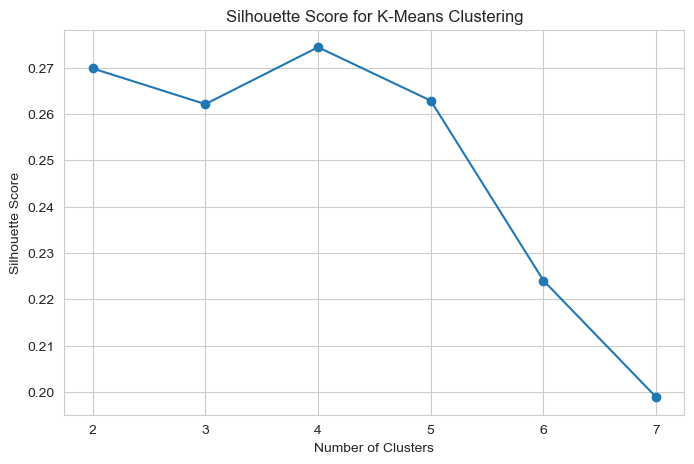

Best Number of Clusters: 4
Best Silhouette Score: 0.2744


In [111]:
# Plotting silhouette scores across cluster counts
plt.figure(figsize=(8, 5))
# Drawing the silhouette score trend
plt.plot(
cluster_values,
silhouette_values,
marker="o"
)
# Adding the plot heading
plt.title("Silhouette Score for K-Means Clustering")
# Labeling the cluster count axis
plt.xlabel("Number of Clusters")
# Labeling the silhouette score axis
plt.ylabel("Silhouette Score")
# Showing all tested cluster counts
plt.xticks(list(cluster_values))
# Displaying the silhouette score plot
plt.show()
# Selecting the cluster count with the highest score
best_cluster_count = cluster_values[
np.argmax(silhouette_values)
]
# Showing the selected cluster count
print(
"Best Number of Clusters:",
best_cluster_count
)
# Showing the highest silhouette score
print(
"Best Silhouette Score:",
round(max(silhouette_values), 4)
)

Silhouette score analysis is used to assess the clustering performance for various number of clusters in the K-Means model. The highest silhouette score of 0.2744 is achieved with four clusters, indicating the most suitable segmentation. More than 4 clusters leads to a lower silhouette score, indicating less separation between the clusters. Four clusters will give a good structure with more clear-cut customer segments.

**Creating the Final K-Means Customer Clusters**

The selected cluster count was used to build the final K-Means model and assign each customer to a cluster. Labels were clustered to the original customers data and the number of customers in each group was shown.

In [112]:
# Building the final K-Means model
final_kmeans = KMeans(
n_clusters=best_cluster_count,
random_state=42,
n_init=10
)
# Assigning each customer to a cluster
customer_clusters = final_kmeans.fit_predict(
cluster_matrix
)
# Copying the original customer data for clustering results
telco_clustered = telco_data.copy()
# Adding the assigned cluster labels
telco_clustered["Cluster"] = customer_clusters
# Showing the number of customers in each cluster
print("Customer Count by Cluster:")
print(
telco_clustered["Cluster"].value_counts().sort_index()
)

Customer Count by Cluster:
Cluster
0    1526
1    1849
2     994
3    2674
Name: count, dtype: int64


**Visualizing Customer Clusters with PCA**

PCA reduced the clustering matrix to two principal components for easier visualization. The data of the customers groups were plotted on the two components to illustrate the separation between the groups.

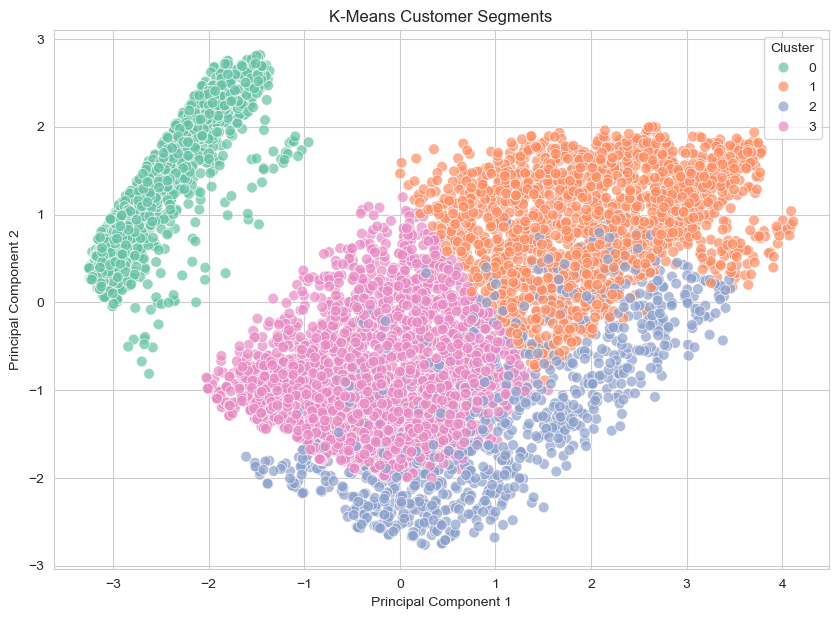

In [113]:
# Reducing clustering data to two principal components
pca_model = PCA(
n_components=2,
random_state=42
)
# Transforming clustering values into PCA coordinates
pca_coordinates = pca_model.fit_transform(
cluster_matrix
)
# Building a dataframe for PCA cluster visualization
pca_cluster_data = pd.DataFrame({
"PC1": pca_coordinates[:, 0],
"PC2": pca_coordinates[:, 1],
"Cluster": customer_clusters
})
# Setting the PCA cluster plot size
plt.figure(figsize=(10, 7))
# Displaying customer groups across two principal components
sns.scatterplot(
data=pca_cluster_data,
x="PC1",
y="PC2",
hue="Cluster",
palette="Set2",
s=60,
alpha=0.7
)
# Adding the PCA visualization title
plt.title("K-Means Customer Segments")
# Naming the first principal component axis
plt.xlabel("Principal Component 1")
# Naming the second principal component axis
plt.ylabel("Principal Component 2")
# Showing the cluster labels
plt.legend(title="Cluster")
# Displaying the customer segment plot
plt.show()

The K-Means clustering plot shows the customers clustered into 4 segments in the reduced feature space. Cluster 1 represents a large group with higher values on Principal Component 2, indicating common customer characteristics. Cluster 0 is a different group with different patterns, and Clusters 2 and 3 have some overlap in customer behavior. The segmentation identifies distinct customer segments, which aids in targeted marketing actions and decision-making.

**Calculating Numerical Cluster Profiles**

The mean numerical values were obtained to summarize characteristics of the customers in each cluster. Results were rounded and presented to facilitate the comparison of customer segments.

In [114]:
# Calculating average numerical values for each cluster
cluster_profile = telco_clustered.groupby(
"Cluster"
)[
[
"SeniorCitizen",
"tenure",
"MonthlyCharges",
"TotalCharges"
]
].mean().round(2)
# Displaying the numerical cluster profiles
print("Numerical Cluster Profiles:")
display(cluster_profile)

Numerical Cluster Profiles:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Cluster,,,,
0,0.03,30.55,21.08,662.69
1,0.05,59.30,89.64,5308.54
2,1.00,29.37,80.45,2476.09
3,0.00,15.91,66.65,1035.39


**Calculating Churn Rates Across Customer Clusters**

The percentage of customers who churned was calculated separately for each cluster. Churn rate by cluster gives a comparison of retention by the identified customer clusters.

In [115]:
# Measuring the percentage of churned customers within each cluster
cluster_churn = telco_clustered.groupby(
"Cluster"
)["Churn"].apply(
lambda values: (values == "Yes").mean() * 100
).round(2)
# Displaying churn percentages for each customer segment
print("Churn Rate by Cluster:")
display(cluster_churn)

Churn Rate by Cluster:


Cluster
0     7.40
1    12.66
2    46.58
3    39.60
Name: Churn, dtype: float64

**Analyzing Contract Distribution by Customer Cluster**

The percentage distribution was used to compare the different types of contracts between different clusters of customers. The resulting table highlights differences in contract preferences among the identified customer segments.

In [116]:
# Calculating contract percentages within each customer cluster
contract_cluster_table = pd.crosstab(
telco_clustered["Cluster"],
telco_clustered["Contract"],
normalize="index"
) * 100
# Displaying contract composition across customer segments
print("Contract Distribution by Cluster:")
display(contract_cluster_table.round(2))

Contract Distribution by Cluster:


Contract,Month-to-month,One year,Two year
Cluster,,,
0,34.34,23.85,41.81
1,20.12,30.56,49.32
2,79.48,15.29,5.23
3,81.86,14.66,3.48


**Creating Customer Transactions for Pattern Mining**

A number of service, contract, billing, security and churn attributes were selected for being converted to transaction-type records. Mining frequent patterns: Each customer record was described as a set of attribute-value pairs.

In [117]:
# Choosing categorical attributes for transaction analysis
pattern_columns = [
"Contract",
"InternetService",
"PaymentMethod",
"PaperlessBilling",
"OnlineSecurity",
"OnlineBackup",
"DeviceProtection",
"TechSupport",
"Churn"
]
# Building transaction records for each customer
pattern_transactions = []
# Converting customer attributes into transaction items
for _, customer in telco_data[pattern_columns].iterrows():
    # Creating an empty item collection for the customer
    customer_items = []
    # Processing each selected customer attribute
    for column in pattern_columns:
        # Combining the attribute name with its observed value
        item_name = f"{column}={customer[column]}"
        customer_items.append(item_name)
    # Saving the completed customer transaction
    pattern_transactions.append(
        customer_items
    )
# Showing sample transaction records
print("Example Transactions:")
for transaction in pattern_transactions[:5]:
    print(transaction)

Example Transactions:
['Contract=Month-to-month', 'InternetService=DSL', 'PaymentMethod=Electronic check', 'PaperlessBilling=Yes', 'OnlineSecurity=No', 'OnlineBackup=Yes', 'DeviceProtection=No', 'TechSupport=No', 'Churn=No']
['Contract=One year', 'InternetService=DSL', 'PaymentMethod=Mailed check', 'PaperlessBilling=No', 'OnlineSecurity=Yes', 'OnlineBackup=No', 'DeviceProtection=Yes', 'TechSupport=No', 'Churn=No']
['Contract=Month-to-month', 'InternetService=DSL', 'PaymentMethod=Mailed check', 'PaperlessBilling=Yes', 'OnlineSecurity=Yes', 'OnlineBackup=Yes', 'DeviceProtection=No', 'TechSupport=No', 'Churn=Yes']
['Contract=One year', 'InternetService=DSL', 'PaymentMethod=Bank transfer (automatic)', 'PaperlessBilling=No', 'OnlineSecurity=Yes', 'OnlineBackup=No', 'DeviceProtection=Yes', 'TechSupport=Yes', 'Churn=No']
['Contract=Month-to-month', 'InternetService=Fiber optic', 'PaymentMethod=Electronic check', 'PaperlessBilling=Yes', 'OnlineSecurity=No', 'OnlineBackup=No', 'DeviceProtection

**Encoding Customer Transactions**

The transaction records were encoded into a binary matrix by the transaction encoder. Every attribute-value pair was converted into a column, and boolean values were used to show if an item was present in any purchases in each transaction.

In [118]:
# Initializing the transaction encoding utility
transaction_encoder = TransactionEncoder()
# Learning unique transaction items and encoding each record
encoded_array = transaction_encoder.fit(
pattern_transactions
).transform(
pattern_transactions
)
# Converting encoded transactions into a DataFrame
transaction_matrix = pd.DataFrame(
encoded_array,
columns=transaction_encoder.columns_
)
# Displaying the dimensions of the encoded matrix
print(
"Transaction Matrix Shape:",
transaction_matrix.shape
)
# Showing the first encoded transaction records
display(transaction_matrix.head())

Transaction Matrix Shape: (7043, 26)


,Churn=No,Churn=Yes,Contract=Month-to-month,Contract=One year,Contract=Two year,DeviceProtection=No,DeviceProtection=No internet service,DeviceProtection=Yes,InternetService=DSL,InternetService=Fiber optic,...,OnlineSecurity=Yes,PaperlessBilling=No,PaperlessBilling=Yes,PaymentMethod=Bank transfer (automatic),PaymentMethod=Credit card (automatic),PaymentMethod=Electronic check,PaymentMethod=Mailed check,TechSupport=No,TechSupport=No internet service,TechSupport=Yes
0,True,False,True,False,False,True,False,False,True,False,...,False,False,True,False,False,True,False,True,False,False
1,True,False,False,True,False,False,False,True,True,False,...,True,True,False,False,False,False,True,True,False,False
2,False,True,True,False,False,True,False,False,True,False,...,True,False,True,False,False,False,True,True,False,False
3,True,False,False,True,False,False,False,True,True,False,...,True,True,False,True,False,False,False,False,False,True
4,False,True,True,False,False,True,False,False,False,True,...,False,False,True,False,False,True,False,True,False,False


**Generating Frequent Customer Itemsets**

The minimum support value of 5% was used to identify frequent itemsets using Apriori algorithm. The sizes of the items in the itemsets were computed and the computed itemsets were sorted by support to show the most common combinations of customer attributes.

In [119]:
# Generating frequent combinations using the Apriori algorithm
frequent_itemsets = apriori(
transaction_matrix,
min_support=0.05,
use_colnames=True
)
# Measuring the number of attributes contained in each itemset
frequent_itemsets["itemset_length"] = (
frequent_itemsets["itemsets"].apply(len)
)
# Ordering itemsets from highest to lowest support
frequent_itemsets = frequent_itemsets.sort_values(
by="support",
ascending=False
)
# Reporting the total number of frequent itemsets
print(
"Number of Frequent Itemsets:",
len(frequent_itemsets)
)
# Displaying the twenty most supported itemsets
display(
frequent_itemsets.head(20)
)

Number of Frequent Itemsets: 2100


,support,itemsets,itemset_length
0,0.734630,(Churn=No),1
18,0.592219,(PaperlessBilling=Yes),1
2,0.550192,(Contract=Month-to-month),1
14,0.496663,(OnlineSecurity=No),1
23,0.493114,(TechSupport=No),1
9,0.439585,(InternetService=Fiber optic),1
5,0.439443,(DeviceProtection=No),1
11,0.438450,(OnlineBackup=No),1
17,0.407781,(PaperlessBilling=No),1
42,0.393440,"(Churn=No, PaperlessBilling=Yes)",2


**Generating and Evaluating Association Rules**

The frequent itemsets were mined to create the association rules with a minimum confidence of 50%. The rules whose lift was above 1 were kept and ranked to find more powerful associations between the attributes of customers.

In [120]:
# Deriving association rules from the frequent itemsets
customer_rules = association_rules(
frequent_itemsets,
metric="confidence",
min_threshold=0.50
)
# Retaining rules with positive association strength
customer_rules = customer_rules[
customer_rules["lift"] > 1
].copy()
# Ranking rules according to their lift values
customer_rules = customer_rules.sort_values(
by="lift",
ascending=False
)
# Reporting the number of retained association rules
print(
"Number of Association Rules:",
len(customer_rules)
)
# Displaying the strongest customer attribute relationships
display(
customer_rules[
[
"antecedents",
"consequents",
"support",
"confidence",
"lift"
]
].head(20)
)

Number of Association Rules: 17511


,antecedents,consequents,support,confidence,lift
13425,"(TechSupport=No internet service, Contract=Two...","(OnlineBackup=No internet service, PaperlessBi...",0.065739,0.725705,5.065553
13424,"(OnlineBackup=No internet service, Contract=Tw...","(TechSupport=No internet service, PaperlessBil...",0.065739,0.725705,5.065553
13413,"(InternetService=No, Contract=Two year)","(PaperlessBilling=No, OnlineSecurity=No intern...",0.065739,0.725705,5.065553
13411,"(OnlineSecurity=No internet service, Contract=...","(PaperlessBilling=No, InternetService=No, Chur...",0.065739,0.725705,5.065553
12555,"(InternetService=No, Contract=Two year)","(OnlineBackup=No internet service, PaperlessBi...",0.065739,0.725705,5.065553
12553,"(OnlineBackup=No internet service, Contract=Tw...","(PaperlessBilling=No, InternetService=No, Chur...",0.065739,0.725705,5.065553
12541,"(TechSupport=No internet service, Contract=Two...","(DeviceProtection=No internet service, Paperle...",0.065739,0.725705,5.065553
12540,"(DeviceProtection=No internet service, Contrac...","(TechSupport=No internet service, PaperlessBil...",0.065739,0.725705,5.065553
13267,"(TechSupport=No internet service, InternetServ...","(DeviceProtection=No internet service, OnlineB...",0.065739,0.725705,5.065553
13265,"(TechSupport=No internet service, OnlineSecuri...","(DeviceProtection=No internet service, OnlineB...",0.065739,0.725705,5.065553


**Formatting Association Rules for Readability**

The antecedent and consequent itemsets were converted to readable text values to make them easier to interpret. The strongest association rules were rounded and displayed for the support, confidence, and lift values.

In [121]:
# Converting antecedent itemsets into readable text
customer_rules["Antecedent"] = customer_rules[
"antecedents"
].apply(
lambda items: ", ".join(sorted(items))
)
# Converting consequent itemsets into readable text
customer_rules["Consequent"] = customer_rules[
"consequents"
].apply(
lambda items: ", ".join(sorted(items))
)
# Preparing a simplified association rules table
readable_rules = customer_rules[
[
"Antecedent",
"Consequent",
"support",
"confidence",
"lift"
]
].copy()
# Rounding association rule evaluation values
readable_rules[
["support", "confidence", "lift"]
] = readable_rules[
["support", "confidence", "lift"]
].round(4)
# Displaying the highest-ranked association rules
display(
readable_rules.head(15)
)

,Antecedent,Consequent,support,confidence,lift
13425,"Contract=Two year, TechSupport=No internet ser...","Churn=No, OnlineBackup=No internet service, Pa...",0.0657,0.7257,5.0656
13424,"Contract=Two year, OnlineBackup=No internet se...","Churn=No, PaperlessBilling=No, TechSupport=No ...",0.0657,0.7257,5.0656
13413,"Contract=Two year, InternetService=No","Churn=No, OnlineSecurity=No internet service, ...",0.0657,0.7257,5.0656
13411,"Contract=Two year, OnlineSecurity=No internet ...","Churn=No, InternetService=No, PaperlessBilling=No",0.0657,0.7257,5.0656
12555,"Contract=Two year, InternetService=No","Churn=No, OnlineBackup=No internet service, Pa...",0.0657,0.7257,5.0656
12553,"Contract=Two year, OnlineBackup=No internet se...","Churn=No, InternetService=No, PaperlessBilling=No",0.0657,0.7257,5.0656
12541,"Contract=Two year, TechSupport=No internet ser...","Churn=No, DeviceProtection=No internet service...",0.0657,0.7257,5.0656
12540,"Contract=Two year, DeviceProtection=No interne...","Churn=No, PaperlessBilling=No, TechSupport=No ...",0.0657,0.7257,5.0656
13267,"Contract=Two year, InternetService=No, TechSup...","Churn=No, DeviceProtection=No internet service...",0.0657,0.7257,5.0656
13265,"Contract=Two year, OnlineSecurity=No internet ...","Churn=No, DeviceProtection=No internet service...",0.0657,0.7257,5.0656


**Visualizing Association Rule Strength**

Association rules were represented graphically with respect to the two key dimensions support and confidence. The size of the points and shading indicated the strength of the relationships between the customer attributes.

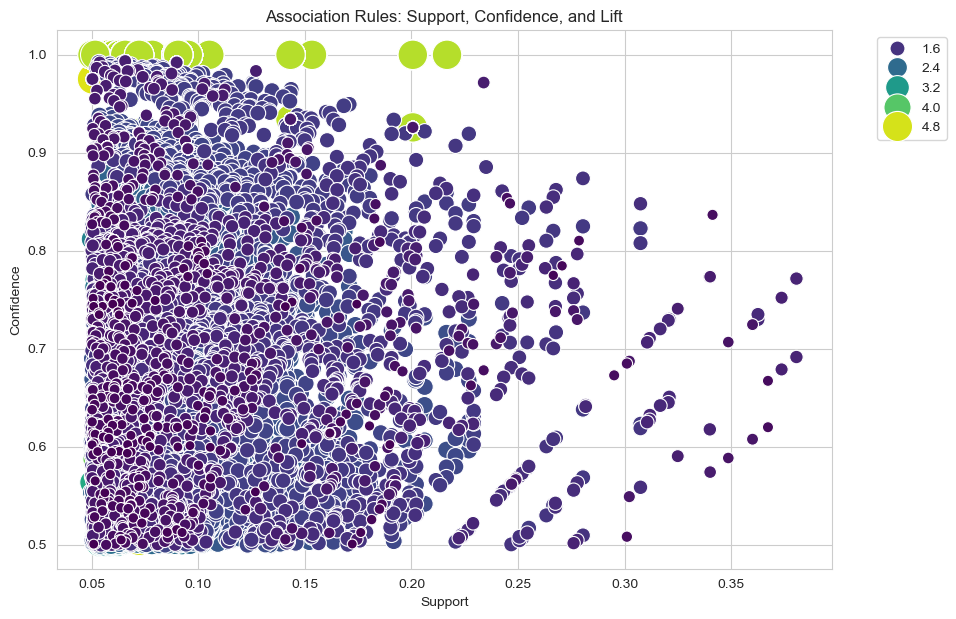

In [122]:
# Preparing the association rule scatter plot
plt.figure(figsize=(10, 7))
# Mapping support and confidence across association rules
sns.scatterplot(
data=customer_rules,
x="support",
y="confidence",
size="lift",
hue="lift",
sizes=(50, 500),
palette="viridis"
)
# Adding the visualization heading
plt.title("Association Rules: Support, Confidence, and Lift")
# Naming the support axis
plt.xlabel("Support")
# Naming the confidence axis
plt.ylabel("Confidence")
# Positioning the lift legend outside the chart
plt.legend(
bbox_to_anchor=(1.05, 1),
loc="upper left"
)
# Rendering the association rule visualization
plt.show()

The association rules are concentrated in the moderate-high range with moderate-high confidence between 0.5 and 1.0. The values of the supports for most rules are low, meaning that a small number of rules are associated with data in the dataset with high support. The magnitude of the lift is shown by the size and brightness of the points: larger and brighter points indicate that there are fewer but stronger relationships between items. Based on the distribution, there are several potential meaningful relationships which need to be investigated further according to the lift and support.

**Identifying Strong Churn-Related Association Rules**

Association rules leading to customer churn were isolated by selecting rules containing Churn=Yes as the consequent. The cleaned rules were then ranked by lift and presented in the most suitable format to find the most significant customer patterns for churn.

In [123]:
# Filtering rules that result in customer churn
churn_rules = customer_rules[
customer_rules["consequents"].apply(
lambda items: "Churn=Yes" in items
)
].copy()
# Ranking churn-related rules by lift strength
churn_rules = churn_rules.sort_values(
by="lift",
ascending=False
)
# Preparing a readable table of churn associations
churn_rule_table = churn_rules[
[
"Antecedent",
"Consequent",
"support",
"confidence",
"lift"
]
].copy()
# Rounding association metrics for clearer presentation
churn_rule_table[
["support", "confidence", "lift"]
] = churn_rule_table[
["support", "confidence", "lift"]
].round(4)
# Reporting the strongest churn-related patterns
print("Strongest Churn-Related Association Rules:")
# Displaying the highest-ranked churn rules
display(
churn_rule_table.head(15)
)

Strongest Churn-Related Association Rules:


,Antecedent,Consequent,support,confidence,lift
15432,"DeviceProtection=No, OnlineSecurity=No, Paperl...","Churn=Yes, Contract=Month-to-month, InternetSe...",0.0585,0.5407,3.2771
16076,"OnlineBackup=No, OnlineSecurity=No, PaperlessB...","Churn=Yes, Contract=Month-to-month, InternetSe...",0.0574,0.5394,3.2693
15428,"Contract=Month-to-month, DeviceProtection=No, ...","Churn=Yes, PaperlessBilling=Yes, TechSupport=No",0.0585,0.5189,3.2227
16611,"DeviceProtection=No, InternetService=Fiber opt...","Churn=Yes, Contract=Month-to-month, TechSuppor...",0.0537,0.6097,3.1807
16071,"Contract=Month-to-month, InternetService=Fiber...","Churn=Yes, PaperlessBilling=Yes, TechSupport=No",0.0574,0.5095,3.1641
16614,"InternetService=Fiber optic, OnlineBackup=No, ...","Churn=Yes, Contract=Month-to-month, DeviceProt...",0.0537,0.5115,3.1629
16072,"Contract=Month-to-month, InternetService=Fiber...","Churn=Yes, OnlineSecurity=No, TechSupport=No",0.0574,0.5580,3.1441
16626,"DeviceProtection=No, InternetService=Fiber opt...","Churn=Yes, Contract=Month-to-month, OnlineSecu...",0.0537,0.5287,3.1421
15431,"DeviceProtection=No, InternetService=Fiber opt...","Churn=Yes, Contract=Month-to-month, PaperlessB...",0.0585,0.5545,3.1268
16613,"DeviceProtection=No, OnlineBackup=No, OnlineSe...","Churn=Yes, Contract=Month-to-month, InternetSe...",0.0537,0.5157,3.1256


**Comparing Final Classification Models**

The results of the Decision Tree, KNN and tuned Decision Tree models were combined into one comparison table. Values of accuracy, F1 score and ROC-AUC were rounded for descriptive purposes, to facilitate the assessment of the model.

In [124]:
# Combining evaluation results from all classification models
final_model_results = pd.DataFrame({
"Model": [
"Decision Tree",
"KNN",
"Tuned Decision Tree"
],
"Accuracy": [
dt_accuracy,
knn_accuracy,
tuned_dt_accuracy
],
"F1 Score": [
dt_f1,
knn_f1,
tuned_dt_f1
],
"ROC-AUC": [
dt_auc,
knn_auc,
tuned_dt_auc
]
})
# Rounding model evaluation metrics
final_model_results[
["Accuracy", "F1 Score", "ROC-AUC"]
] = final_model_results[
["Accuracy", "F1 Score", "ROC-AUC"]
].round(4)
# Displaying the final model comparison
display(final_model_results)

,Model,Accuracy,F1 Score,ROC-AUC
0,Decision Tree,0.7942,0.5821,0.8265
1,KNN,0.7672,0.5556,0.8019
2,Tuned Decision Tree,0.7509,0.5585,0.7871


**Selecting the Best Classification Model**

The final comparison table was used to obtain the highest F1 score, which meant that the classification model was chosen. The F1 score corresponding to the selected model was displayed as a summary of the model's performance along with the ROC-AUC value.

In [125]:
# Identifying the model with the strongest F1 score
best_model_row = final_model_results.loc[
final_model_results["F1 Score"].idxmax()
]
# Displaying the selected classification model
print(
"Best Classification Model:",
best_model_row["Model"]
)
# Showing the highest F1 score
print(
"Best F1 Score:",
best_model_row["F1 Score"]
)
# Showing the ROC-AUC score of the selected model
print(
"Best ROC-AUC:",
best_model_row["ROC-AUC"]
)

Best Classification Model: Decision Tree
Best F1 Score: 0.5821
Best ROC-AUC: 0.8265


**Summarizing the Complete Customer Churn Analysis**

The results of classification, clustering and association rule mining were summarized into a single analytical result. Overall, the size of the dataset, the quality of the clusters, the frequent itemsets, and the number of association rules were reported.

In [126]:
# Reporting the complete analytical summary
print("ANALYSIS SUMMARY")
# Summarizing the dataset dimensions
print("\nDataset:")
print(f"Customers analyzed: {len(telco_data):,}")
print(f"Variables available: {telco_data.shape[1]}")
# Reporting the best classification model results
print("\nClassification:")
print(
f"Best Model: {best_model_row['Model']}"
)
print(
f"Best Accuracy: {best_model_row['Accuracy']:.4f}"
)
print(
f"Best F1 Score: {best_model_row['F1 Score']:.4f}"
)
print(
f"Best ROC-AUC: {best_model_row['ROC-AUC']:.4f}"
)
# Summarizing the selected customer clusters
print("\nClustering:")
print(
f"Selected Clusters: {best_cluster_count}"
)
print(
f"Best Silhouette Score: "
f"{max(silhouette_values):.4f}"
)
# Reporting the pattern mining results
print("\nPattern Mining:")
print(
f"Frequent Itemsets: {len(frequent_itemsets)}"
)
print(
f"Association Rules: {len(customer_rules)}"
)
# Confirming completion of the analytical workflow
print("\nAnalysis completed successfully.")

ANALYSIS SUMMARY

Dataset:
Customers analyzed: 7,043
Variables available: 21

Classification:
Best Model: Decision Tree
Best Accuracy: 0.7942
Best F1 Score: 0.5821
Best ROC-AUC: 0.8265

Clustering:
Selected Clusters: 4
Best Silhouette Score: 0.2744

Pattern Mining:
Frequent Itemsets: 2100
Association Rules: 17511

Analysis completed successfully.


The analysis summary provides a detailed evaluation of customer information consisting of 7043 records and 21 variables. The highest accuracy is obtained from the Decision Tree model, which has 79.42%, F1 score of 0.5821, and ROC AUC of 0.8265. A silhouette score of 0.2744 is obtained in the clustering analysis showing a moderate separation of the customer segments. It finds 2,100 frequent itemsets and 17,511 association rules, which offers important insights into customers' behaviors.